In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import impuls_simulator as impuls_simulator
import ifb_selectors as selector

In [9]:
def spike_interval_by_peak(data, threshold_factor=2):
    data = np.array(data)
    baseline = np.median(data)
    uplift = np.std(data)
    threshold = baseline + threshold_factor*uplift

    left,right = 0,0
    # 1. Znajdź największy peak powyżej thresholdu
    idx_peak = np.argmax(data)
    if data[idx_peak] < threshold:
        return None, None, None  # brak impulsu

    # 2. Rozszerz w lewo
    left = idx_peak
    while left > 0 and data[left] > threshold:
        left -= 1
    # 3. Rozszerz w prawo
    right = idx_peak
    while right < len(data)-1 and data[right] > threshold:
        right += 1

    return left, right, threshold

def bandpass_filter(signal, fs, f_low, f_high):
    # Wykonanie FFT
    fft_signal = np.fft.fft(signal)
    freqs = np.fft.fftfreq(len(signal), 1/fs)
    
    # Tworzenie maski dla wybranego pasma
    mask = (abs(freqs) >= f_low) & (abs(freqs) <= f_high)
    
    # Aplikacja maski (wyzerowanie składowych poza wybranym pasmem)
    fft_signal_filtered = fft_signal.copy()
    fft_signal_filtered[~mask] = 0
    
    # Odwrotna transformata Fouriera
    filtered_signal = np.real(np.fft.ifft(fft_signal_filtered))
    
    return filtered_signal, freqs, fft_signal, fft_signal_filtered

def impuls_detection(filtered,impuls_threshold):
    filtered_energy  = np.sum(filtered**2)
    impulses = (filtered > np.mean(filtered) + impuls_threshold*np.std(filtered)) | (filtered < np.mean(filtered) - impuls_threshold*np.std(filtered))

    filtered_no_impulses = filtered.copy()
    filtered_no_impulses[impulses] = 0
    filtered_no_impulses_energy = np.sum(filtered_no_impulses**2)
    return filtered_no_impulses_energy/filtered_energy

def calculate_analysis(signal, filter_threshold=1, impuls_threshold=1):
    #spektrogram
    fs = len(signal)
    array_freq, array_tt, matrix_Zxx = scipy.signal.stft(signal, fs = fs, window = 'hann')
    Zxx = np.abs(matrix_Zxx)
    
    selector_functions = [selector.SK, selector.JB, selector.KSS, selector.AD, selector.CVM, selector.CVS]
    left_list = []
    right_list = []

    for selektor in selector_functions:
        results = selektor(Zxx)
        left, right, threshold = spike_interval_by_peak(results,filter_threshold)
        if left is not None:
            left_list.append(array_freq[left])
        if right is not None:
            right_list.append(array_freq[right])

    left = np.median(np.array(left_list))            
    right = np.median(np.array(right_list))
    print(left)
    print(right)

    #filtracja na podstawie otrzymanych granic
    filtered, _, _, _ = bandpass_filter(signal, fs, left, right)
    sigma = np.std(filtered)
    mu = np.mean(filtered)
    upper_threshold_filtered = mu + impuls_threshold*sigma
    lower_threshold_filtered = mu - impuls_threshold*sigma

    filtered_energy  = np.sum(filtered**2)
    impulses = (filtered > upper_threshold_filtered) | (filtered < lower_threshold_filtered)

    filtered_no_impulses = filtered.copy()
    filtered_no_impulses[impulses] = 0
    filtered_no_impulses_energy = np.sum(filtered_no_impulses**2)

    return filtered_no_impulses_energy/filtered_energy

def draw_analysis(signal, filter_threshold=1, impuls_threshold=1):
    #sygnał w czasie
    plt.figure(figsize=(10, 4))
    plt.plot(signal, linewidth=1)
    plt.title(f"Sygnał w czasie")
    plt.xlabel("Próbka")
    plt.ylabel("Amplituda")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    #spektrogram
    fs = len(signal)
    array_freq, array_tt, matrix_Zxx = scipy.signal.stft(signal, fs = fs, window = 'hann')
    Zxx = np.abs(matrix_Zxx)
    plt.figure(figsize=(18, 6))
    plt.pcolormesh(array_freq, array_tt, 10*np.log10(Zxx.T), shading='gouraud', cmap='plasma')
    plt.xlabel('Częstotliwość [Hz]')
    plt.ylabel('Czas [s]')
    plt.title('Spektrogram')
    plt.colorbar(label='Amplituda [dB]')
    plt.show()

    #selektor
    selector_functions = [selector.SK, selector.JB, selector.KSS, selector.AD, selector.CVM, selector.CVS]
    left_list = []
    right_list = []

    for selektor in selector_functions:
        results = selektor(Zxx)
        left, right, threshold = spike_interval_by_peak(results,filter_threshold)
        if left is not None:
            left_list.append(array_freq[left])
        if right is not None:
            right_list.append(array_freq[right])

    left = np.median(np.array(left_list))            
    right = np.median(np.array(right_list))
    print(left)
    print(right)

    #wyrysowanie wykresów
    plt.figure(figsize=(18,5))
    plt.plot(array_freq,results)
    plt.axvline(x=left, color = "red", linestyle = "--")
    plt.axvline(x=right, color = "red", linestyle = "--")
    plt.axhline(y=threshold, color = "green", linestyle = "--")
    plt.title("Wyniki selektora")
    plt.xlabel("Częstotliwość")
    plt.ylabel("Wartość selektora")
    plt.grid()


    filtered, _, _, _ = bandpass_filter(signal, fs, left, right)
    mu = np.mean(filtered)
    sigma = np.std(filtered)
    upper_border = mu + impuls_threshold*sigma
    lower_border = mu - impuls_threshold*sigma

    plt.figure(figsize=(18,5))
    plt.plot(filtered)
    plt.axhline(y=upper_border, color = "red", linestyle = "--")
    plt.axhline(y=lower_border, color = "red", linestyle = "--")
    plt.title("Sygnał po filtracji")
    plt.xlabel("Czas")
    plt.ylabel("Amplituda")
    plt.grid()

def draw_all_selectors(signal):
    #spektrogram
    fs = len(signal)
    array_freq, array_tt, matrix_Zxx = scipy.signal.stft(signal, fs = fs, window = 'hann')
    Zxx = np.abs(matrix_Zxx)


    results_list = [
    ("SK", selector.SK(Zxx)),
    ("JB", selector.JB(Zxx)),
    ("KSS", selector.KSS(Zxx)),
    ("AD", selector.AD(Zxx)),
    ("CVM", selector.CVM(Zxx)),
    ("CVS", selector.CVS(Zxx))
    ]

    freq = np.linspace(0,25000,len(array_freq))

    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    axes = axes.ravel()

    for ax, (title, results) in zip(axes, results_list):
        ax.plot(array_freq, results)
        ax.set_title(f"Wyniki selektora: {title}")
        ax.set_xlabel("Częstotliwość")
        ax.set_ylabel("Wartość selektora")
        ax.grid()

    plt.tight_layout()
    plt.show()

def plot_all_selectors_grid(sigma, fmod):
    # 6 selektorów + ich nazwy
    selector_functions = [
        ("SK", selector.SK),
        ("JB", selector.JB),
        ("KSS", selector.KSS),
        ("AD", selector.AD),
        ("CVM", selector.CVM),
        ("CVS", selector.CVS)
    ]

    # Trzy poziomy B
    B_levels = {
        "Low (5σ)": 5 * sigma,
        "Mid (10σ)": 10 * sigma,
        "High (20σ)": 20 * sigma
    }

    colors = [
        "red",
        "blue",
        "green",
        "orange",
        "purple",
        "brown"
    ]

    fig, axes = plt.subplots(len(selector_functions), 3, figsize=(18, 20))
    fig.suptitle("Selektory dla różnych poziomów amplitudy impulsów", fontsize=16)

    for row, ((sel_name, sel_fun), color) in enumerate(zip(selector_functions, colors)):
        for col, (label, B) in enumerate(B_levels.items()):

            # Generowanie nowego sygnału
            signal = impuls_simulator.gen_signal(B=B, fmod=fmod, sigma=sigma)

            # STFT / Spectrogram / Zxx musi być wygenerowane tak jak u Ciebie:
            # (zakładam, że masz coś takiego i używasz dokładnie tak jak wcześniej)
            fs=len(signal)
            array_freq, array_tt, matrix_Zxx =  scipy.signal.stft(signal,fs=fs, window = 'hann')
            Zxx = np.abs(matrix_Zxx)

            # Wyliczamy dany selektor
            results = sel_fun(Zxx)

            # rysowanie
            ax = axes[row, col]
            ax.plot(array_freq, results, color=color)
            ax.grid()
            ax.set_title(f"{sel_name} – {label}")

            if col == 0:
                ax.set_ylabel(sel_name)
            if row == len(selector_functions) - 1:
                ax.set_xlabel("Częstotliwość [Hz]")

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

def plot_all_selectors_grid_from_signals(signals, fs, signal_labels=None):
    """
    signals        – lista sygnałów 1D (np. [s1, s2, s3])
    fs             – częstotliwość próbkowania
    signal_labels  – opcjonalne opisy kolumn
    """

    selector_functions = [
        ("SK",  selector.SK),
        ("JB",  selector.JB),
        ("KSS", selector.KSS),
        ("AD",  selector.AD),
        ("CVM", selector.CVM),
        ("CVS", selector.CVS)
    ]

    colors = ["red", "blue", "green", "orange", "purple", "brown"]

    n_rows = len(selector_functions)
    n_cols = len(signals)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 20))
    fig.suptitle("Selektory dla różnych sygnałów", fontsize=16)

    if signal_labels is None:
        signal_labels = [f"Sygnał {i+1}" for i in range(n_cols)]

    for col, signal in enumerate(signals):

        # STFT dla danego sygnału
        array_freq, array_tt, Zxx = scipy.signal.stft(
            signal, fs=fs, window='hann'
        )
        Zxx = np.abs(Zxx)

        for row, ((sel_name, sel_fun), color) in enumerate(
            zip(selector_functions, colors)
        ):

            results = sel_fun(Zxx)

            ax = axes[row, col] if n_cols > 1 else axes[row]
            ax.plot(array_freq, results, color=color)
            ax.grid()
            ax.set_title(f"{sel_name} – {signal_labels[col]}")

            if col == 0:
                ax.set_ylabel(sel_name)

            if row == n_rows - 1:
                ax.set_xlabel("Częstotliwość [Hz]")

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


# Przygotowanie danych

### Pobranie danych z pliku

In [ ]:
from scipy.io import loadmat



data = loadmat('assets/datasets/daniel/signal_early.mat')
signal1 = data["signal_early"][:,0]

data = loadmat('assets/datasets/daniel/signal_medium_fault.mat')
signal2 = data["signal_medium_fault"][:,0]

data = loadmat('assets/datasets/daniel/signal_developed_fault.mat')
signal3 = data["signal_developed_fault"][:,0]

signals = [signal1,signal2,signal3]
plot_all_selectors_grid_from_signals(signals,fs = len(signal1),signal_labels=["Słaba usterka","Średnia usterka","Rozwinięta usterka"])

# draw_analysis(signal,selector.CVS)
# draw_all_selectors(signal)

## Wyrysowanie wszystkich sygnałów i ich spektrogramów

In [ ]:
#sygnał w czasie

fig, axes = plt.subplots(3, 2, figsize=(20, 10))

axes[0,0].plot(signal1, linewidth=1)
axes[0,0].set_title(f"Sygnał w czasie")
axes[0,0].set_xlabel("Próbka")
axes[0,0].set_ylabel("Amplituda")
axes[0,0].grid(True)

axes[1,0].plot(signal2, linewidth=1)
axes[1,0].set_title(f"Sygnał w czasie")
axes[1,0].set_xlabel("Próbka")
axes[1,0].set_ylabel("Amplituda")
axes[1,0].grid(True)

axes[2,0].plot(signal3, linewidth=1)
axes[2,0].set_title(f"Sygnał w czasie")
axes[2,0].set_xlabel("Próbka")
axes[2,0].set_ylabel("Amplituda")
axes[2,0].grid(True)

#spektrogram
fs = len(signal1)
array_freq, array_tt, matrix_Zxx = scipy.signal.stft(signal1, fs = fs, window = 'hann')
Zxx = np.abs(matrix_Zxx)
im = axes[0,1].pcolormesh(array_freq, array_tt, 10*np.log10(Zxx.T), shading='gouraud', cmap='plasma',label='Amplituda [dB]')
axes[0,1].set_xlabel('Częstotliwość [Hz]')
axes[0,1].set_ylabel('Czas [s]')
axes[0,1].set_title('Spektrogram')
# axes[0,1].set_colorbar(label='Amplituda [dB]')

fs = len(signal2)
array_freq, array_tt, matrix_Zxx = scipy.signal.stft(signal2, fs = fs, window = 'hann')
Zxx = np.abs(matrix_Zxx)
axes[1,1].pcolormesh(array_freq, array_tt, 10*np.log10(Zxx.T), shading='gouraud', cmap='plasma',label='Amplituda [dB]')
axes[1,1].set_xlabel('Częstotliwość [Hz]')
axes[1,1].set_ylabel('Czas [s]')
axes[1,1].set_title('Spektrogram')
# axes[1,1].colorbar(label='Amplituda [dB]')

fs = len(signal3)
array_freq, array_tt, matrix_Zxx = scipy.signal.stft(signal3, fs = fs, window = 'hann')
Zxx = np.abs(matrix_Zxx)
axes[2,1].pcolormesh(array_freq, array_tt, 10*np.log10(Zxx.T), shading='gouraud', cmap='plasma',label='Amplituda [dB]')
axes[2,1].set_xlabel('Częstotliwość [Hz]')
axes[2,1].set_ylabel('Czas [s]')
axes[2,1].set_title('Spektrogram')
# axes[2,1].colorbar(label='Amplituda [dB]')

plt.tight_layout()

In [ ]:
# wczytanie pliku
data = loadmat('assets/datasets/Healthy/H1.mat')
print(data.keys())
signal1 = data["H"][:,1]
data = loadmat('assets/datasets/Faulty/F1.mat')
print(data.keys())
signal2 = data["H"][:,1]

plot_all_selectors_grid_from_signals([signal1,signal2],fs=10000)

# Wygenerowanie danych

In [ ]:
B=15
fs=25000
varsize=25000
fmod=30
f_center=2000
bandwidth=500
shift=0
sigma=1
signal = impuls_simulator.gen_signal(B,fs,varsize,fmod,f_center,bandwidth,shift,sigma)
draw_analysis(signal,selector.SK,impuls_threshold=3)
draw_all_selectors(signal)

In [ ]:
print(calculate_analysis(signal,selector.JB,impuls_threshold=3))

In [ ]:
signal1 = impuls_simulator.gen_signal(B=0.5,fmod=30,sigma=0.1)
signal2 = impuls_simulator.gen_signal(B=1,fmod=30,sigma=0.1)
signal3 = impuls_simulator.gen_signal(B=2,fmod=30,sigma=0.1)
plot_all_selectors_grid_from_signals([signal1,signal2,signal3],fs=25000)

signal1 = impuls_simulator.gen_signal(15,fs,varsize,fmod,f_center,bandwidth,shift,3)
signal2 = impuls_simulator.gen_signal(30,fs,varsize,fmod,f_center,bandwidth,shift,3)
signal3 = impuls_simulator.gen_signal(60,fs,varsize,fmod,f_center,bandwidth,shift,3)
plot_all_selectors_grid_from_signals([signal1,signal2,signal3],fs=25000)

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(20, 10))

signal1 = impuls_simulator.gen_signal(B=0.5,fmod=30,sigma=0.1)
signal2 = impuls_simulator.gen_signal(B=1,fmod=30,sigma=0.1)
signal3 = impuls_simulator.gen_signal(B=2,fmod=30,sigma=0.1)

axes[0,0].plot(signal1, linewidth=1)
axes[0,0].set_title(f"Sygnał w czasie")
axes[0,0].set_xlabel("Próbka")
axes[0,0].set_ylabel("Amplituda")
axes[0,0].grid(True)

axes[1,0].plot(signal2, linewidth=1)
axes[1,0].set_title(f"Sygnał w czasie")
axes[1,0].set_xlabel("Próbka")
axes[1,0].set_ylabel("Amplituda")
axes[1,0].grid(True)

axes[2,0].plot(signal3, linewidth=1)
axes[2,0].set_title(f"Sygnał w czasie")
axes[2,0].set_xlabel("Próbka")
axes[2,0].set_ylabel("Amplituda")
axes[2,0].grid(True)

#spektrogram
fs = len(signal1)
array_freq, array_tt, matrix_Zxx = scipy.signal.stft(signal1, fs = fs, window = 'hann')
Zxx = np.abs(matrix_Zxx)
im = axes[0,1].pcolormesh(array_freq, array_tt, 10*np.log10(Zxx.T), shading='gouraud', cmap='plasma',label='Amplituda [dB]')
axes[0,1].set_xlabel('Częstotliwość [Hz]')
axes[0,1].set_ylabel('Czas [s]')
axes[0,1].set_title('Spektrogram')
# axes[0,1].set_colorbar(label='Amplituda [dB]')

fs = len(signal2)
array_freq, array_tt, matrix_Zxx = scipy.signal.stft(signal2, fs = fs, window = 'hann')
Zxx = np.abs(matrix_Zxx)
axes[1,1].pcolormesh(array_freq, array_tt, 10*np.log10(Zxx.T), shading='gouraud', cmap='plasma',label='Amplituda [dB]')
axes[1,1].set_xlabel('Częstotliwość [Hz]')
axes[1,1].set_ylabel('Czas [s]')
axes[1,1].set_title('Spektrogram')
# axes[1,1].colorbar(label='Amplituda [dB]')

fs = len(signal3)
array_freq, array_tt, matrix_Zxx = scipy.signal.stft(signal3, fs = fs, window = 'hann')
Zxx = np.abs(matrix_Zxx)
axes[2,1].pcolormesh(array_freq, array_tt, 10*np.log10(Zxx.T), shading='gouraud', cmap='plasma',label='Amplituda [dB]')
axes[2,1].set_xlabel('Częstotliwość [Hz]')
axes[2,1].set_ylabel('Czas [s]')
axes[2,1].set_title('Spektrogram')
plt.tight_layout()

# Selektory

In [ ]:
plot_all_selectors_grid(3,30)

In [ ]:
plot_all_selectors_grid(0.1,30)

# Analiza: filtracja i ocena

6835.937499999999
6982.421874999999
0.959718255501602


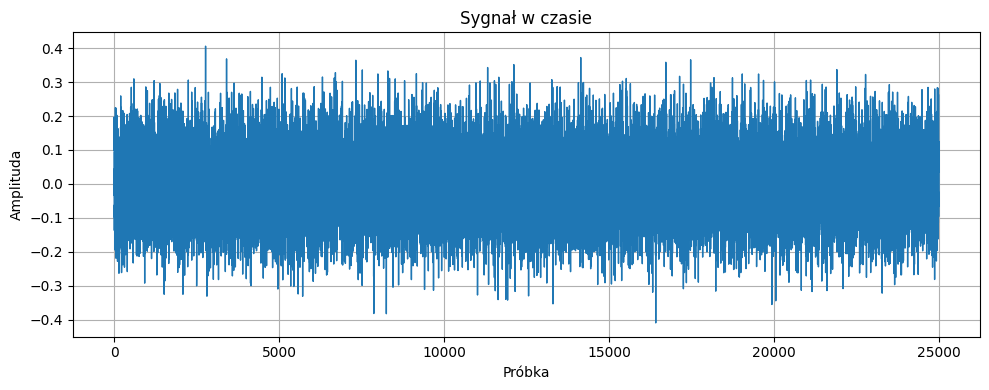

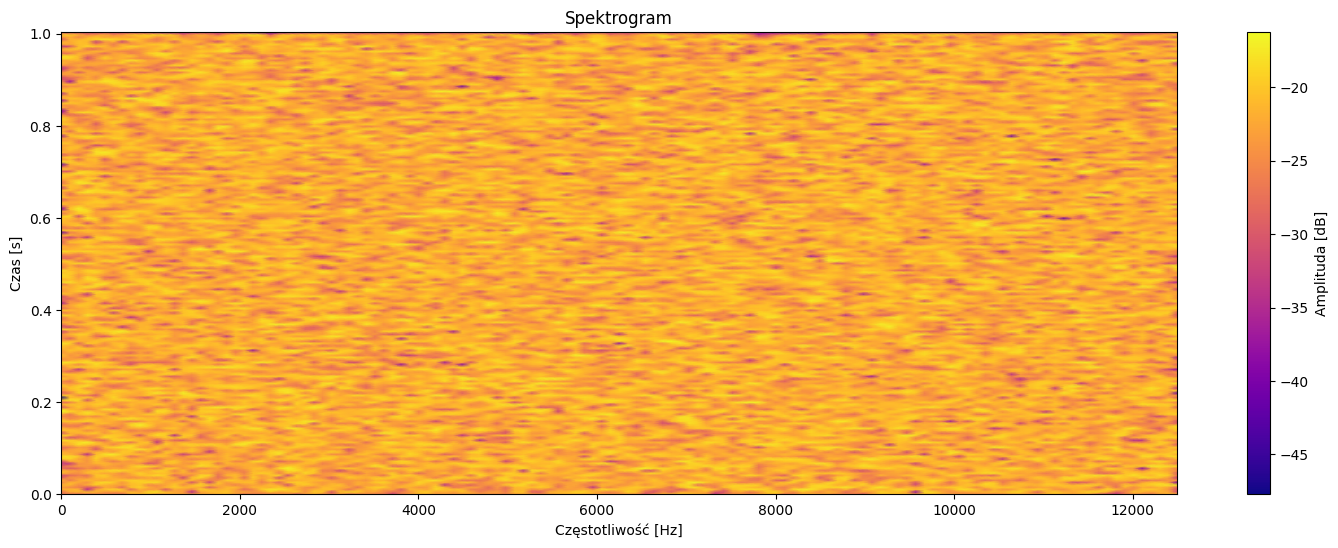

6835.937499999999
6982.421874999999


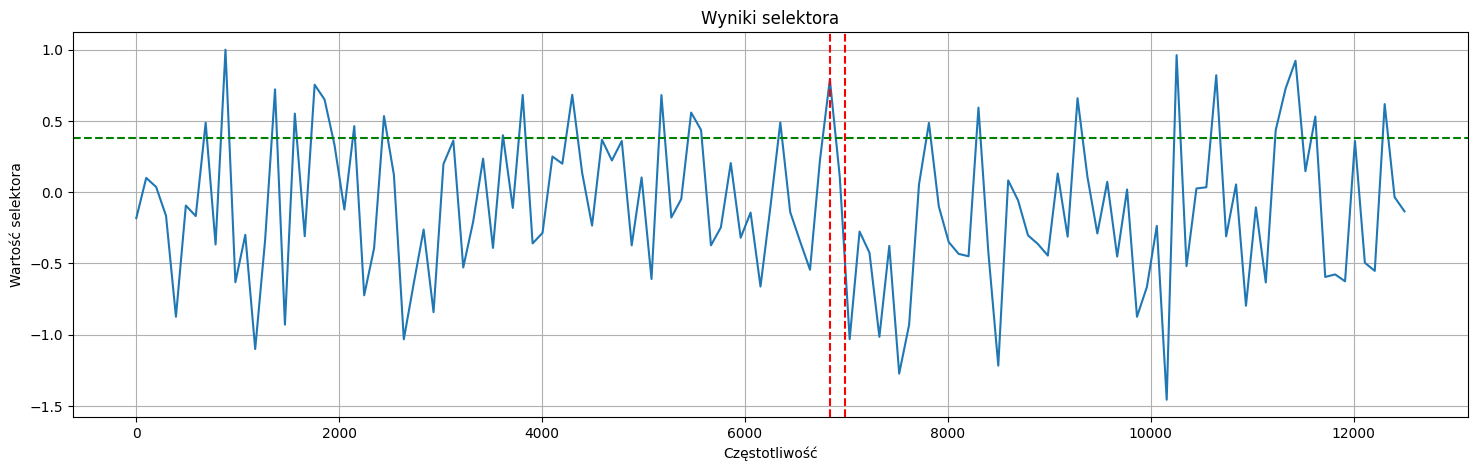

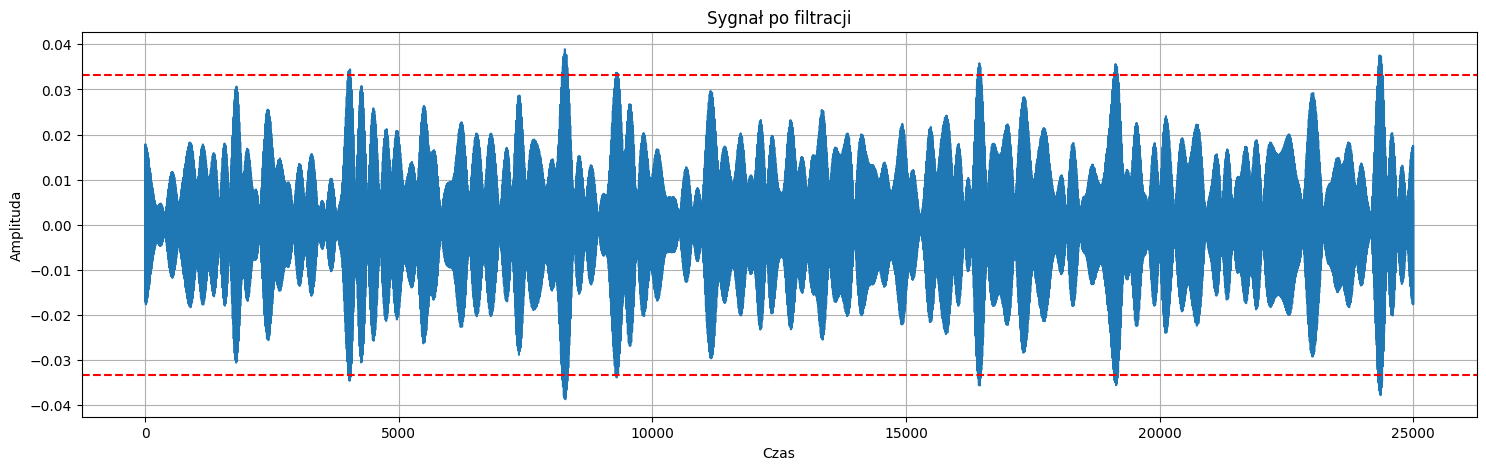

In [11]:
signal = impuls_simulator.gen_signal(B=0,fmod=30,sigma=0.1)
print(calculate_analysis(signal,1,3))
draw_analysis(signal,1,3)

In [ ]:
signal = impuls_simulator.gen_signal(B=1,fmod=30,sigma=0.1)
print(calculate_analysis(signal,1,3))
draw_analysis(signal,1,3)
draw_all_selectors(signal)